# Monatliche Telekom-Netzwerk-KPIs: Datenverbrauchsbalken mit ARPU- und Kündigungslinien (PROC GBARLINE)

## Zusammenfassung

Dieses Notebook nutzt **PROC GBARLINE**, um ein vertikales Balkendiagramm des monatlichen mobilen Datenverbrauchs mit überlagerten Linienplots für ARPU, Kündigungsquote und Support-Tickets zu kombinieren — das klassische "Zwei-Achsen"-KPI-Dashboard, das ein Telekom-Analyst baut, um zu erkennen, ob steigender Verbrauch sich tatsächlich in Umsatz und Kundenbindung übersetzt. Es erzeugt inline synthetische Datensätze je Abonnent, und übt dann die Anweisungen BAR und LINE mit Untergruppen, benutzerdefinierten rechten Achsen, Referenzsymbolen und Legenden aus.

## Datenquellen

**Datensatz: `telco_kpi`** — synthetische Datensätze je Abonnent und Monat (4 Monate x 3 Tarifstufen x 8 Abonnenten = 96 Zeilen), inline erzeugt mit `call streaminit(20260531)`. Das Panel wird bei 96 Zeilen gehalten, damit es bequem innerhalb der 100-Beobachtungs-Grenze des nicht lizenzierten Modus bleibt und jeder Monat und jede Tarifstufe vollständig besetzt bleibt.

| Variable | Typ | Beschreibung |
|----------|------|--------------|
| `month`  | Char | Kalendermonatskürzel (Jan–Apr) |
| `plan`   | Char | Tarifstufe: Prepaid, Postpaid, Familie |
| `data_gb`| Num  | Monatlich verbrauchte mobile Daten, in GB (Gamma-verteilt, mit sanftem saisonalem Anstieg und langsamem Wachstum) |
| `arpu`   | Num  | Durchschnittlicher Umsatz je Nutzer, in USD (steigt mit Tarifstufe und über die Monate) |
| `churn`  | Num  | Monatliches Kündigungskennzeichen (0/1, Bernoulli; höher früh im Zeitraum und bei günstigeren Tarifstufen) |
| `tickets`| Num  | Eröffnete Support-Tickets (Poisson-Zähler) |

# Monatliche Telekom-Netzwerk-KPIs mit PROC GBARLINE

Telekombetreiber leben und sterben mit einer Handvoll monatlicher KPIs: wie viele **Daten** Abonnenten verbrauchen, welchen **ARPU** (durchschnittlicher Umsatz je Nutzer) dieser Verbrauch erzeugt, wie viele Kunden **kündigen**, und wie hoch die **Support-Ticket**-Last dahinter ist. Diese Kennzahlen leben auf sehr unterschiedlichen Skalen — Gigabyte, Dollar und kleine Zähler — sodass das Plotten auf einer einzigen Antwortachse die Geschichte verbirgt.

`PROC GBARLINE` ist genau dafür gebaut: Es zeichnet ein vertikales **Balken**diagramm gegen die linke Achse und überlagert einen oder mehrere **Linien**plots gegen eine unabhängige rechte Achse. In diesem Notebook bauen wir ein Verbrauchs-vs-Umsatz-Dashboard und schichten dann schrittweise Tarifebenen-Untergruppen, eine benutzerdefinierte rechte Achse und Mehrlinien-Überlagerungen ein.

## Schritt 1 — Erzeugung synthetischer Abonnent-Monats-Daten

Der DATA-Step unten fabriziert ein realistisches Panel: 4 Monate (Jan–Apr) über 3 Tarifstufen (Prepaid, Postpaid, Familie) mit je 8 Abonnenten, für 96 Zeilen insgesamt. Wir setzen den RNG-Seed mit `call streaminit` für Reproduzierbarkeit und ziehen jede KPI aus einer domänenpassenden Verteilung:

- **Datenverbrauch** aus einer Gammaverteilung mit sanftem saisonalem Anstieg und langsamem Monat-über-Monat-Wachstum.
- **ARPU** steigend mit Tarifstufe und über die Monate, mit normalem Rauschen.
- **Kündigung** als Bernoulli-Kennzeichen, das früh im Zeitraum und bei günstigeren Tarifstufen höher ist.
- **Support-Tickets** als Poisson-Zähler, leicht schwerer früh im Jahr.

Es werden keine externen Dateien gelesen — alles ist in sich geschlossen, und das 96-Zeilen-Panel bleibt innerhalb der nicht lizenzierten 100-Beobachtungs-Grenze, sodass jeder Monat und jede Tarifstufe gerendert wird.

In [1]:
DATEN telco_kpi;
    AUFRUFEN streaminit(20260531);
    LÄNGE month $4 plan $8;
    AUSFÜHRUNG mi = 1 BIS 4;
        /* Monatsname je Index -- direkte IF/ELSE-Zuweisung statt
           _temporary_-Array, weil ein dollar-breites _temporary_-Array mit
           nicht-ASCII-Werten (z.B. "Mär") auf eine inkonsistent kuerzere
           Byte-Laenge abgeschnitten wird */
        WENN      mi = 1 DANN month = 'Jan';
        SONST WENN mi = 2 DANN month = 'Feb';
        SONST WENN mi = 3 DANN month = 'Mär';
        SONST                month = 'Apr';
        /* sanfter saisonaler Anstieg und langsames Datenwachstum */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        AUSFÜHRUNG plan_i = 1 BIS 3;
            WENN plan_i = 1 DANN plan = 'Prepaid';
            SONST WENN plan_i = 2 DANN plan = 'Postpaid';
            SONST plan = 'Familie';
            AUSFÜHRUNG rep = 1 BIS 8;
                /* monatlich verbrauchte mobile Daten (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* durchschnittlicher Umsatz je Nutzer ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* monatliches Kuendigungskennzeichen, hoeher frueh im Jahr */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* eroeffnete Support-Tickets */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                AUSGABE;
            ENDE;
        ENDE;
    ENDE;
    ENTFERNEN mi plan_i rep season;
AUSFÜHREN;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Schritt 2 — Das Kern-Dashboard: Verbrauchsbalken + ARPU-Linie

Dies ist das kanonische `GBARLINE`-Muster. Die `BAR`-Anweisung zeichnet den mittleren monatlichen Datenverbrauch (`SUMVAR=data_gb TYPE=mean`), und eine einzelne `LINE`-Anweisung überlagert den mittleren ARPU auf der rechten Achse (`STAT=mean TYPE=join`). Wir schalten ODS Graphics ein und geben dem Diagramm einen zweizeiligen Titel. `COUTLINE=` und `WIDTH=` säubern die Balken auf.

                                      Monatlicher mobiler Datenverbrauch und ARPU                                       
                                           Synthetische Telekom-Netzwerk-KPIs                                           




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Monatlicher mobiler Datenverbrauch und ARPU.
NOTE: Option TITLE2 changed to Synthetische Telekom-Netzwerk-KPIs.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


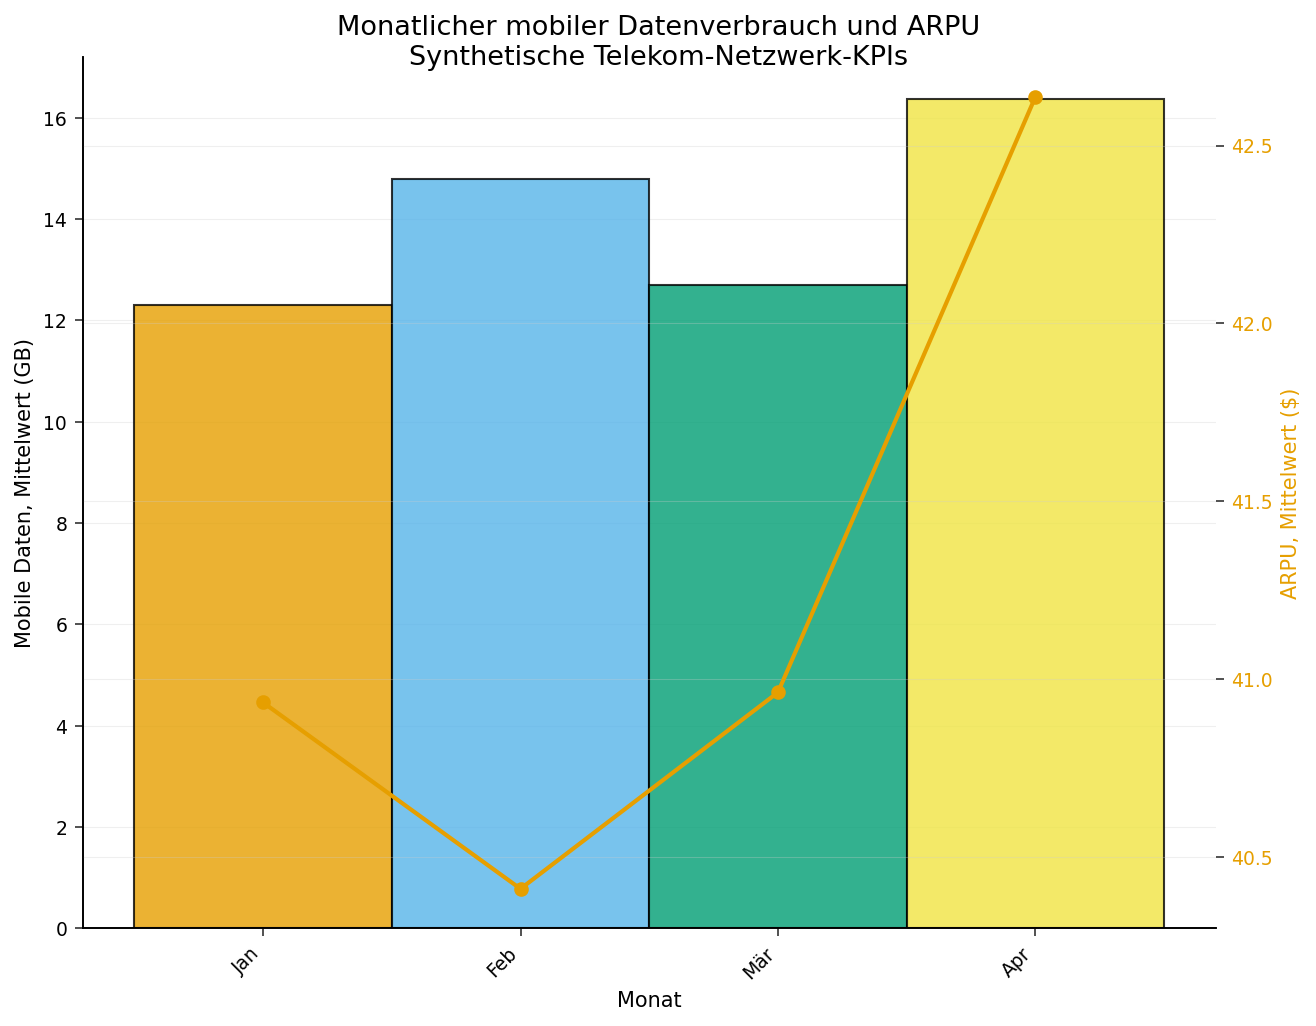

In [2]:
ODS GRAPHICS ON;
TITEL 'Monatlicher mobiler Datenverbrauch und ARPU';
title2 'Synthetische Telekom-Netzwerk-KPIs';

/* axis1 uebernimmt ueber MAXIS= die kategoriale x-Achsenbeschriftung,
   axis2/axis3 ueber RAXIS= die y-Achsenbeschriftungen -- PROC GBARLINE
   leitet die automatisch abgeleitete Achsenbeschriftung sonst aus dem
   ASCII-Variablennamen ab und ignoriert dafuer die LABEL-Anweisung */
PROZEDUR gbarline DATEN=telco_kpi;
    axis1 BEZEICHNUNG="Monat";
    axis2 BEZEICHNUNG="Mobile Daten, Mittelwert (GB)";
    axis3 BEZEICHNUNG="ARPU, Mittelwert ($)";
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6 maxis=axis1 raxis=axis2;
    line arpu / STAT=mean type=JOIN raxis=axis3;
    BEZEICHNUNG month="Monat" data_gb="Mobile Daten (GB)" arpu="ARPU ($)";
AUSFÜHREN;

## Schritt 3 — Verbrauch nach Tarif aufschlüsseln, Kündigungen überlagern

Das Ersetzen von `TYPE=mean` durch `TYPE=sum` und das Hinzufügen von `SUBGROUP=plan` stapelt den Balken jedes Monats nach Tarifstufe, sodass wir sehen können, welches Segment das Gesamtvolumen treibt. Die überlagerte `LINE` zeichnet nun die monatliche **Anzahl** der Kündigungsereignisse als Nadelplot (`STAT=sum TYPE=needle`) — vertikale Spitzen, die sich natürlich als diskrete Ereigniszähler lesen statt als glatter Trend.

                                Datenvolumen nach Tarif mit monatlicher Kündigungsquote                                 
                                           Synthetische Telekom-Netzwerk-KPIs                                           




NOTE: Option TITLE changed to Datenvolumen nach Tarif mit monatlicher Kündigungsquote.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


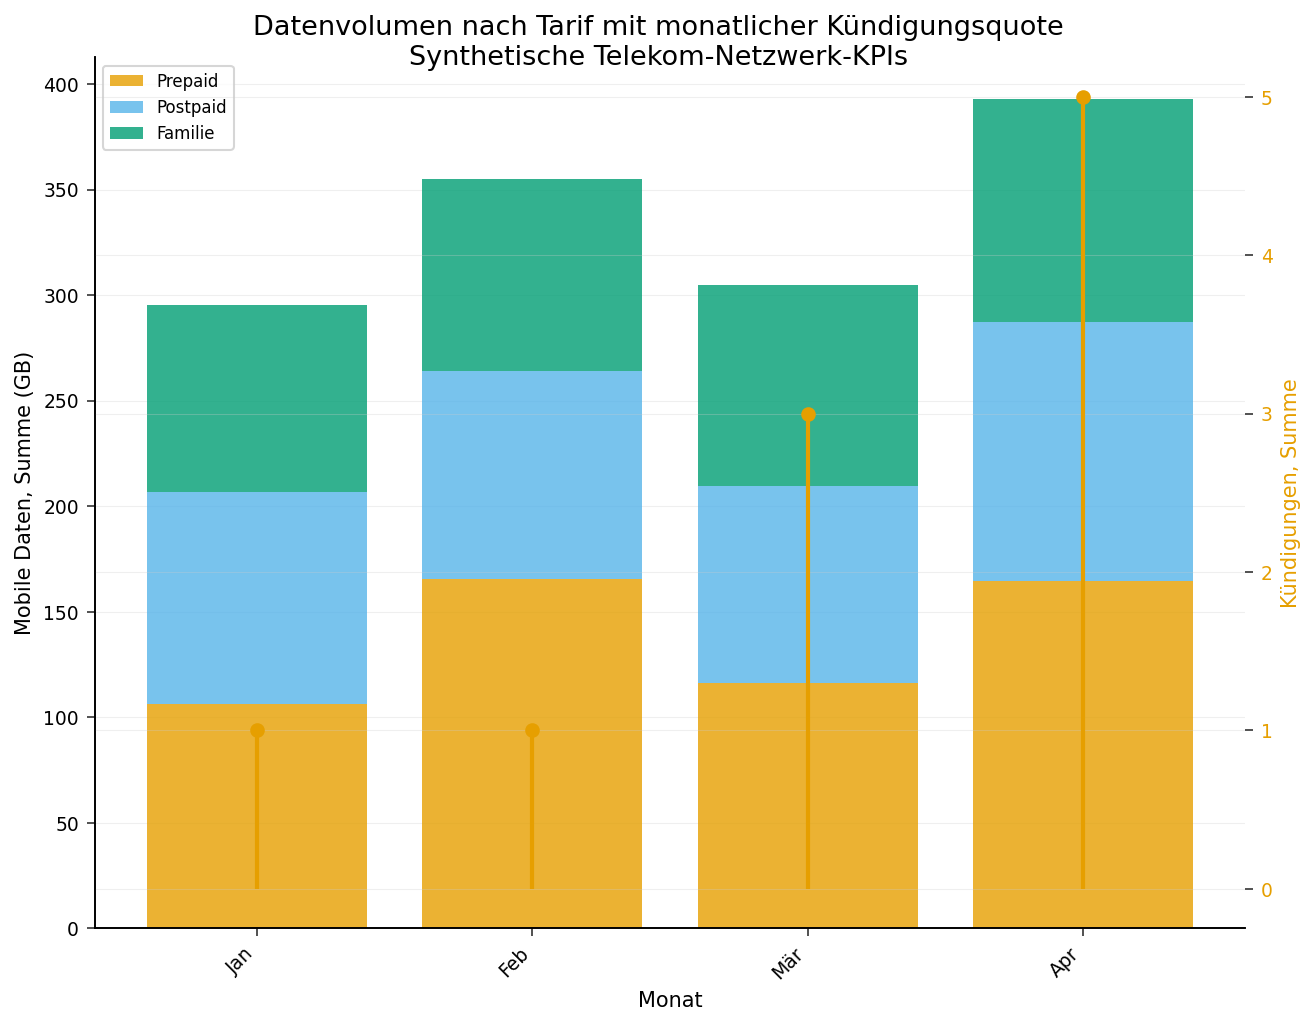

In [3]:
TITEL 'Datenvolumen nach Tarif mit monatlicher Kündigungsquote';

PROZEDUR gbarline DATEN=telco_kpi;
    axis1 BEZEICHNUNG="Monat";
    axis2 BEZEICHNUNG="Mobile Daten, Summe (GB)";
    axis3 BEZEICHNUNG="Kündigungen, Summe";
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan
                maxis=axis1 raxis=axis2;
    line churn / STAT=sum type=needle raxis=axis3;
    BEZEICHNUNG month="Monat" data_gb="Mobile Daten (GB)" plan="Tarif" churn="Kündigungen";
AUSFÜHREN;

## Schritt 4 — Steuerung der rechten Achse und des Linienmarkers

Für ein veröffentlichungsreifes Diagramm fixieren wir die (rechte) Plot-Achse mit einer `AXIS`-Definition auf einen festen Bereich und beschriften sie, dann binden wir sie über `RAXIS=axis2` an die Linie. Eine `SYMBOL`-Definition gibt der ARPU-Linie einen roten gepunkteten Marker. Wir zeigen außerdem die Balkensummen über jedem Balken mit `OUTSIDE=sum` an.

                                  Gesamtverbrauch (Balken) vs. mittlerer ARPU (Linie)                                   
                                           Synthetische Telekom-Netzwerk-KPIs                                           




NOTE: Option TITLE changed to Gesamtverbrauch (Balken) vs. mittlerer ARPU (Linie).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


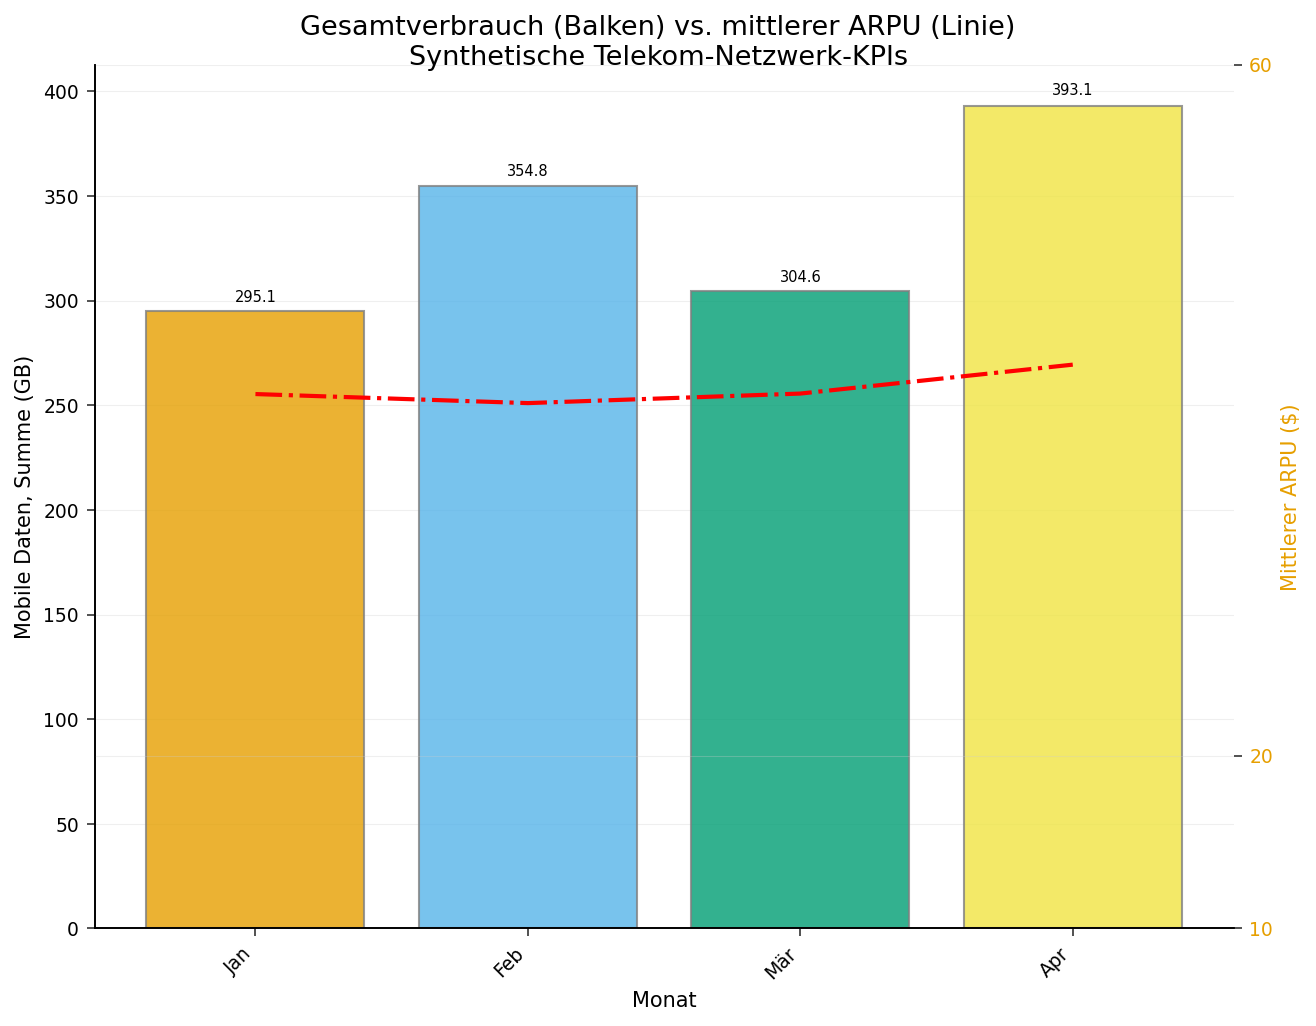

In [4]:
TITEL 'Gesamtverbrauch (Balken) vs. mittlerer ARPU (Linie)';

PROZEDUR gbarline DATEN=telco_kpi;
    axis1 BEZEICHNUNG="Monat";
    axis2 ORDER=(20 BIS 60 NACH 10) BEZEICHNUNG=('Mittlerer ARPU ($)');
    axis3 BEZEICHNUNG="Mobile Daten, Summe (GB)";
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray maxis=axis1 raxis=axis3;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    BEZEICHNUNG month="Monat" data_gb="Mobile Daten (GB)" arpu="ARPU ($)";
AUSFÜHREN;

## Schritt 5 — Mehrere Linienüberlagerungen mit einer benutzerdefinierten Legende

`GBARLINE` akzeptiert mehr als eine `LINE`-Anweisung, sodass wir zwei operative Signale gleichzeitig gegen die Verbrauchsbalken vergleichen können: mittlere Support-Tickets (`type=join`) und Gesamtkündigungen (`type=needle`). Eine unten positionierte `LEGEND`-Definition dokumentiert die Tarif-Untergruppen.

                                          Support-Tickets und Kündigungstrends                                          
                                           Synthetische Telekom-Netzwerk-KPIs                                           




NOTE: Option TITLE changed to Support-Tickets und Kündigungstrends.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


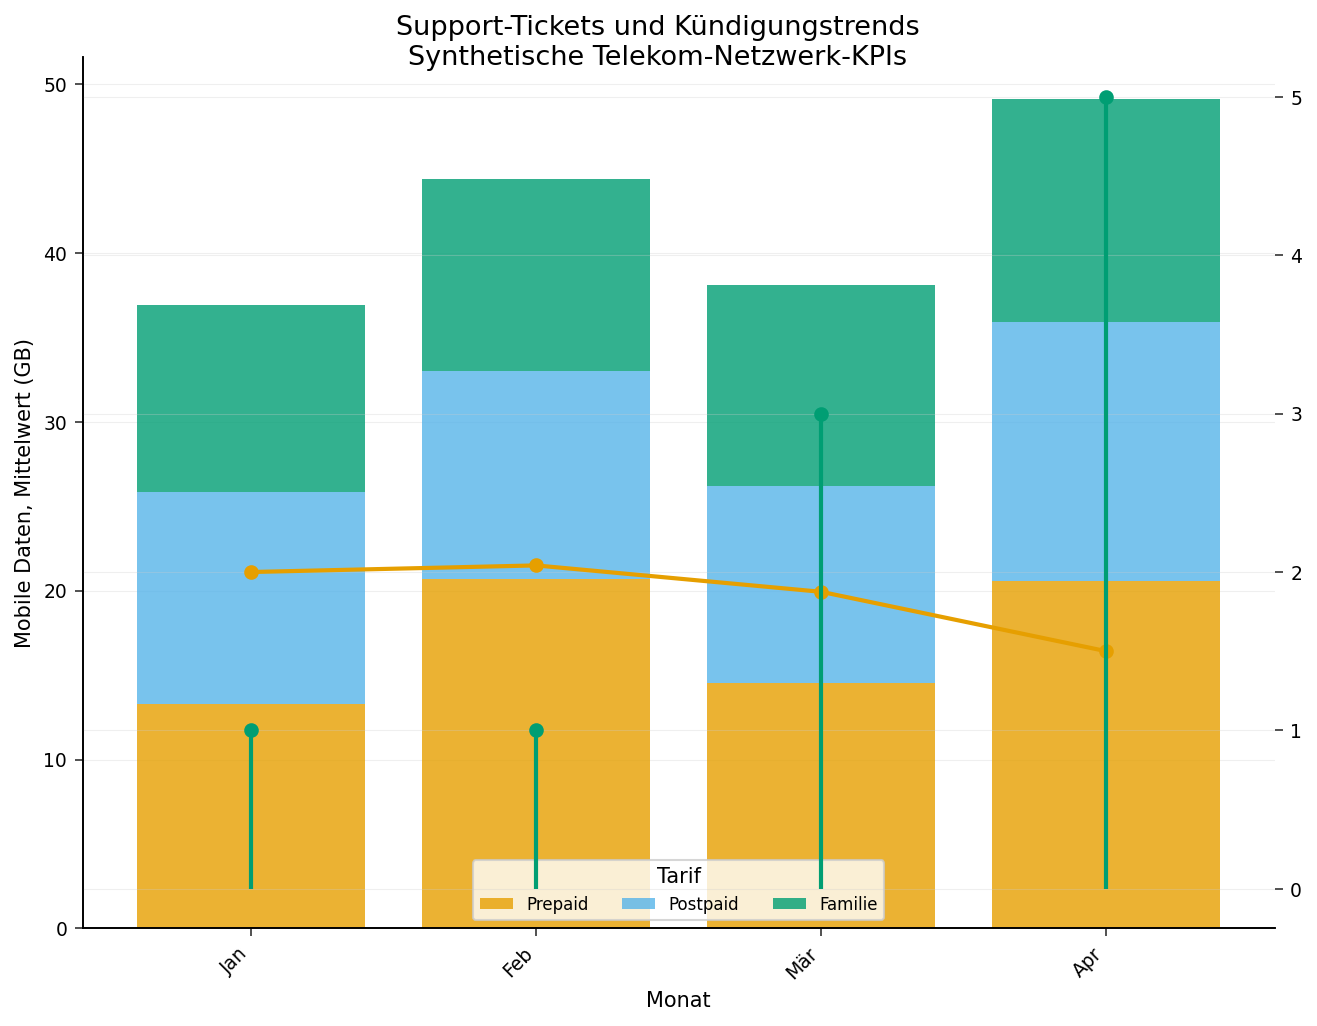

In [5]:
TITEL 'Support-Tickets und Kündigungstrends';

PROZEDUR gbarline DATEN=telco_kpi;
    axis1 BEZEICHNUNG="Monat";
    axis2 BEZEICHNUNG="Mobile Daten, Mittelwert (GB)";
    legend1 BEZEICHNUNG=('Tarif') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1 maxis=axis1 raxis=axis2;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    BEZEICHNUNG month="Monat" data_gb="Mobile Daten (GB)" plan="Tarif"
          tickets="Support-Tickets" churn="Kündigungen";
AUSFÜHREN;

ODS GRAPHICS OFF;

## Interpretation der Ergebnisse

Über das Jan–Apr-Fenster erzählt das Dashboard eine kohärente Telekom-Geschichte. Der **Datenverbrauch** (die Balken) schwankt von Monat zu Monat, tendiert aber nach oben und erreicht im **April** seinen Höhepunkt — der mittlere Verbrauch steigt von etwa 12,3 GB im Januar auf 16,4 GB im April (Schritt 2), und das Gesamtvolumen von 295 GB auf 393 GB (die `OUTSIDE=sum`-Beschriftungen in Schritt 4). Die **ARPU-Linie** sinkt im Februar leicht und steigt dann auf ihr eigenes April-Hoch nahe \$42,6, sodass der Betreiber den zusätzlichen Verbrauch zunehmend monetarisiert, statt ihn zu verschenken — die rechte Achse in Schritt 4 ist auf \$20–\$60 fixiert, um diese Bewegung lesbar zu halten.

Die tarifgestapelten Ansichten (Schritte 3 und 5) offenbaren die Segmentspannung, die prepaid-lastige Betreiber prägt. **Prepaid** (das orangefarbene Band) trägt insgesamt die meisten Gigabyte — rund 553 GB über die vier Monate gegenüber 415 GB für Postpaid und 380 GB für Familie — verdient aber den **niedrigsten** durchschnittlichen Umsatz je Nutzer (etwa \$36, gegenüber \$41 für Postpaid und \$47 für Familie). Die **Kündigungsnadeln** bestätigen, wo das Kündigungsrisiko sitzt: Kündigungsereignisse häufen sich bei den Tarifstufen Prepaid und Postpaid (je 4 Ereignisse über das Fenster) und bleiben bei Familie leichter (2), und sie wachsen zum April hin, während die Abonnentenbasis und der Verbrauch expandieren.

Schritt 5 überlagert die operative Last darüber: Die mittleren **Support-Tickets** laufen früh im Zeitraum etwas schwerer und lassen bis April nach, während die Kündigungsnadeln später ihren Höhepunkt erreichen — die Art von Signal, auf die ein Kundenbindungsteam achtet. Betrieblich lautet der Schluss, die Kundenbindungsausgaben auf **Prepaid**-Abonnenten zu konzentrieren, die die am schnellsten wachsende Scheibe des Datenvolumens verbrauchen, während sie den geringsten Umsatz und die meisten Kündigungen erzeugen.

`PROC GBARLINE` ist hier genau deshalb das richtige Werkzeug, weil es die Balken im Gigabyte-Maßstab und die Linien im Dollar-/Zähler-Maßstab auf unabhängigen Achsen hält, sodass jede KPI auf ihren eigenen Bedingungen gelesen werden kann, während weiterhin die monatliche Zeitachse geteilt wird.